<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/healthcare/object_detection_box.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os
import matplotlib.pyplot as plt
import matplotlib.image as pltimg
import numpy as np
import pandas as pd
import cv2
import torch
import re
from PIL import Image
from torchvision import transforms
from torch import nn
from time import time
import albumentations as A
from torchsummary import summary

In [2]:
# check if the gpu is available or not
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [3]:
# connect to dataset drive
drive.flush_and_unmount()
drive.mount('/content/drive')

In [ ]:
# upload the dataset
!unzip /content/drive/MyDrive/Healthcare/BUSI/BUSI_Jpeg.zip

In [5]:
data_path = ['benign', 'benign_mask', 'malignant', 'malignant_mask']

# check the files and folders
for path in data_path:
  for root, dirs, files in os.walk(path):
    print(f'There are {len(dirs)} directories and  {len(files)} files in "/{root}"')

There are 0 directories and  437 files in "/benign"
There are 0 directories and  455 files in "/benign_mask"
There are 0 directories and  210 files in "/malignant"
There are 0 directories and  212 files in "/malignant_mask"


In [6]:
# Make sure to get the right image file
def extract_idx(filename):
  """
  Extract index from the filename
  """
  index = re.search(r'\((\d+)\)', filename)
  if index is not None:
    return int(index.group(1))
  else: return -1

def is_valid_image(filename, prefix, is_mask=False):
  """
  Make sure the file and the pattern in the dataset match in order to avoid duplicate images
  """
  if is_mask:
    pattern = rf'{prefix} \(\d+\)_mask\.png$'
  else:
      pattern = rf'{prefix} \(\d+\)\.png$'
  return re.match(pattern, filename)

In [7]:
"""
  Clean up the images directories
  read all images in the directory -> extract only images by index in the file -> validate to remove duplicate or invalid image
  sort them based on the index
"""
benign = sorted(
    [f for f in os.listdir('benign') if extract_idx(f) != -1 and is_valid_image(f, 'benign', False)],
    key=extract_idx)
benign_mask = sorted(
    [f for f in os.listdir('benign_mask') if extract_idx(f) != -1 and is_valid_image(f, 'benign', True)],
    key=extract_idx)
malignant = sorted(
    [f for f in os.listdir('malignant') if extract_idx(f) != -1 and is_valid_image(f, 'malignant', False)],
    key=extract_idx)
malignant_mask = sorted(
    [f for f in os.listdir('malignant_mask') if extract_idx(f) != -1 and is_valid_image(f, 'malignant', True)],
    key=extract_idx)

In [8]:
len(benign), len(benign_mask), len(malignant), len(malignant_mask)

(437, 437, 210, 210)

In [9]:
# plot a random image from each classes
def plot_img_with_mask(depth, root):
  idx = np.random.randint(0, depth)
  fig, ax = plt.subplots(1, 5, figsize=(15, 4))

  # orignal image
  org_img = pltimg.imread(f'{root}/{root} ({idx}).png')
  # mask image
  mask_img = pltimg.imread(f'{root}_mask/{root} ({idx})_mask.png')

  # plot orinal img
  ax[0].imshow(org_img)
  ax[0].set_title(f"Orignal {root} ({idx})")
  ax[0].set_xticks([])
  ax[0].set_yticks([])

  # plot the mask img
  ax[1].imshow(mask_img)
  ax[1].set_title(f"Mask {root} ({idx})")
  ax[1].set_xticks([])
  ax[1].set_yticks([])


  print(f'maks_img shape: {mask_img.shape}')

  # add threshold for the mask image
  if len(mask_img.shape) == 3: # <-- if the image is not already in 1 chanel(gray scale)
    imgray = cv2.cvtColor(mask_img, cv2.COLOR_BGR2GRAY)
  else:
    imgray = mask_img

  imgray = (imgray * 255).astype("uint8") # <-- change image type
  _, threshold = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)
  contours, hierarchy = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

  # plot the contours image
  contours_img = cv2.drawContours(mask_img, contours, -1, (127,255,0), 2)
  ax[2].imshow(contours_img)
  ax[2].set_title(f"Contours {root} ({idx})")
  ax[2].set_xticks([])
  ax[2].set_yticks([])

  # masked the original image
  controus_img = org_img.copy()
  contours_org_img = cv2.drawContours(controus_img, contours, -1, (127, 255, 0), 2)
  ax[3].imshow(contours_org_img)
  ax[3].set_title(f'Masked {root} ({idx})', color='red')
  ax[3].set_xticks([])
  ax[3].set_yticks([])

  # Contours bounding box
  bound_img = org_img.copy()
  for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(bound_img, (x, y), (x+w, y+h), (0, 255, 0, 0), 4)
  ax[4].imshow(bound_img)
  ax[4].set_title(f'Bounding Contours {root} ({idx})', color='red')
  ax[4].set_xticks([])
  ax[4].set_yticks([])

  plt.tight_layout()

maks_img shape: (468, 563)


maks_img shape: (473, 551)


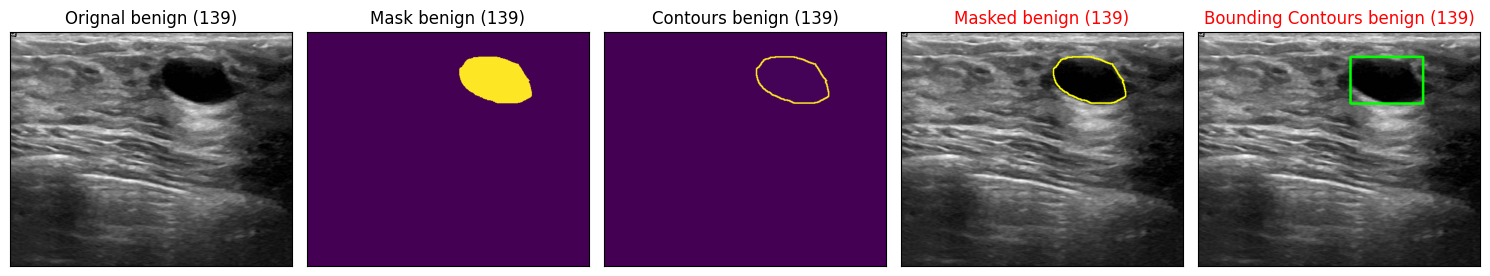

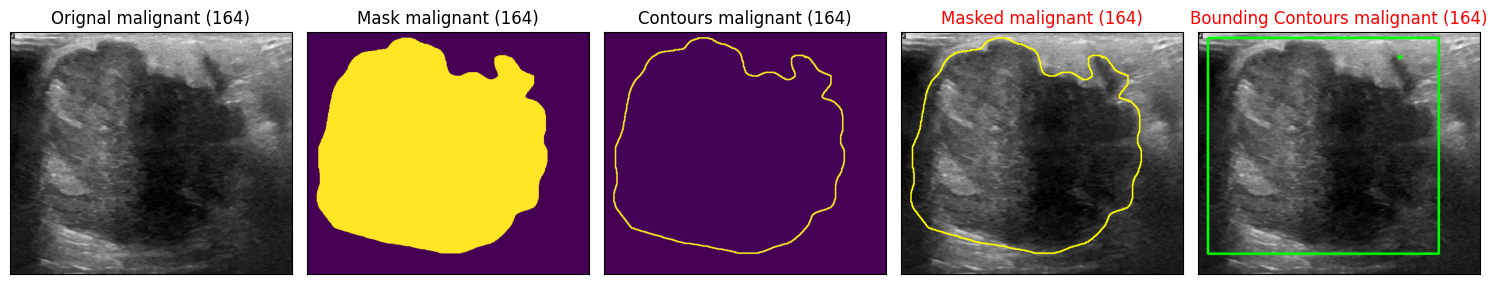

In [ ]:
plot_img_with_mask(len(benign), 'benign')
plot_img_with_mask(len(malignant), 'malignant')

227 128 67 62


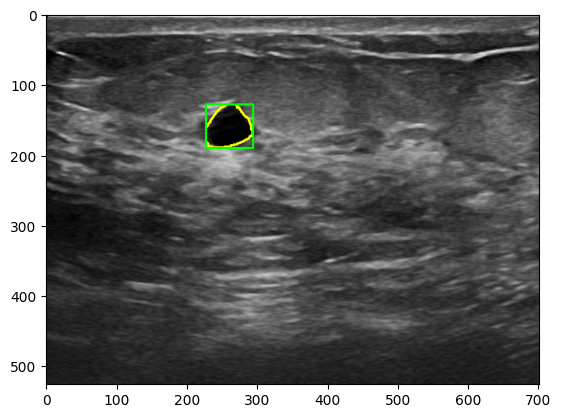

In [ ]:
# add threshold for the mask image
# orignal image
org_img = pltimg.imread(f'benign/benign (15).png')
# mask image
mask_img = pltimg.imread(f'benign_mask/benign (15)_mask.png')

if len(mask_img.shape) == 3: # <-- if the image is not already in 1 chanel(gray scale)
  imgray = cv2.cvtColor(mask_img, cv2.COLOR_BGR2GRAY)
else:
  imgray = mask_img

imgray = (imgray * 255).astype("uint8") # <-- change image type
_, threshold = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

contours_org_img = cv2.drawContours(org_img, contours, -1, (127, 255, 0), 2)
for cnt in contours:
  x, y, w, h = cv2.boundingRect(cnt)
  print(x, y, w, h)
  cv2.rectangle(contours_org_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.imshow(contours_org_img)


In [8]:
# Denormalize method for displying normalized image
g_mean = [0.485, 0.456, 0.406]
g_std = [0.229, 0.224, 0.225]
def denormalize(img):
    if isinstance(img, torch.Tensor):
        mean = torch.tensor(g_mean, device=img.device)
        std = torch.tensor(g_std, device=img.device)
        return img * std[:, None, None] + mean[:, None, None]

    elif isinstance(img, np.ndarray):
        mean = np.array(g_mean)
        std = np.array(g_std)
        return img * std[None, None, :] + mean[None, None, :]

In [9]:
# Providing the mask get the boundry box
def get_bbox_and_cnt(mask):
  if len(mask.shape) == 3:
    imgray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
  else:
    imgray = mask

  imgray = (imgray * 255).astype("uint8") # <-- change image type
  _, threshold = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)

  # get the contours
  contours, _ = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
  if len(contours)==0:
    return None

  # take the largest contour
  cnt = max(contours, key=cv2.contourArea)
  # get the bounding box
  x, y, w, h = cv2.boundingRect(cnt)

  return contours, [x, y, w, h]

In [10]:
# splitting the Benign to training and testing
def split_dataset(data):
  train_size = int(0.7 * len(data)) # 70%
  valid_size = int(0.2 * len(data)) # 20%
  test_size = len(data) - train_size - valid_size # 10%
  generator = torch.Generator().manual_seed(0)
  train, val, test = torch.utils.data.random_split(data, [train_size, valid_size, test_size], generator=generator)
  return train, val, test

In [11]:
class Dataset(torch.utils.data.Dataset):
  def __init__(self, img_list, mask_list, img_dir, mask_dir, transform=None, image_size=None):
    self.img_list = img_list
    self.mask_list = mask_list
    self.img_dir = img_dir
    self.mask_dir = mask_dir
    self.transform = transform
    self.image_size = image_size

  def __len__(self):
    return len(self.img_list)

  def __getitem__(self, index):
    image_path = os.path.join(self.img_dir, self.img_list[index])
    mask_path = os.path.join(self.mask_dir, self.mask_list[index])

    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path)

    image = np.array(image)
    mask = np.array(mask)

    _, bbox = get_bbox_and_cnt(mask)
    if bbox is None:
      bbox = [0, 0, 0, 0]
    if self.transform:
      result = self.transform(image=image, bboxes=[bbox])
      image = result['image']
      bbox = result['bboxes'][0]

    bbox = np.array(bbox)/self.image_size

    return image.float(), torch.tensor(bbox, dtype=torch.float32)

In [12]:
# Create a Augmentation Pipeline
img_size = 512
train_transform_pipeline = A.Compose([
    A.Resize(img_size, img_size),

    # Geometric
    # A.HorizontalFlip(p=0.2),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        p=0.1
    ),

    # A.ElasticTransform(alpha=1, sigma=50, p=0.2), # Simulates tissue deformation
    # A.GridDistortion(p=0.2),

    # Light intensity changes
    A.RandomBrightnessContrast(p=0.1),
    A.GaussNoise(std_range=(0.1, 0.5), p=0.1),

    A.GaussianBlur(
         sigma_limit=(0.2, 0.5),  # Small sigma for subtle blur
         blur_limit=0,            # Auto-compute kernel size
         p=0.2
     ),

    A.Normalize(mean=g_mean, std=g_std ),
    A.pytorch.ToTensorV2(),
],
bbox_params=A.BboxParams(format='coco', min_visibility=0.3, label_fields=[]))
validation_transform_pipeline = A.Compose([
    A.Resize(img_size, img_size),
    A.Normalize(mean=g_mean, std=g_std ),
    A.pytorch.ToTensorV2(),
],
bbox_params=A.BboxParams(format='coco', min_visibility=0.3, label_fields=[]))

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [13]:
# Get all the benign dataset
ben_train_data, ben_val_data, ben_test_data = split_dataset(benign)
ben_train_mask, ben_val_mask, ben_test_mask = split_dataset(benign_mask)
benign_train = Dataset(ben_train_data, ben_train_mask, 'benign', 'benign_mask', transform=train_transform_pipeline, image_size=img_size)
benign_val = Dataset(ben_val_data, ben_val_mask, 'benign', 'benign_mask', transform=validation_transform_pipeline, image_size=img_size)
benign_test = Dataset(ben_test_data, ben_test_mask, 'benign', 'benign_mask', transform=validation_transform_pipeline, image_size=img_size)

In [14]:
# Get all the malignant dataset
mal_train_data, mal_val_data, mal_test_data = split_dataset(malignant)
mal_train_mask, mal_val_mask, mal_test_mask = split_dataset(malignant_mask)
malignant_train = Dataset(mal_train_data, mal_train_mask, 'malignant', 'malignant_mask', transform=train_transform_pipeline, image_size=img_size)
malignant_val = Dataset(mal_val_data, mal_val_mask, 'malignant', 'malignant_mask', transform=validation_transform_pipeline, image_size=img_size)
malignant_test = Dataset(mal_test_data, mal_test_mask, 'malignant', 'malignant_mask', transform=validation_transform_pipeline, image_size=img_size)

In [15]:
img, label = malignant_train.__getitem__(1)
img.shape, label.shape

(torch.Size([3, 512, 512]), torch.Size([4]))

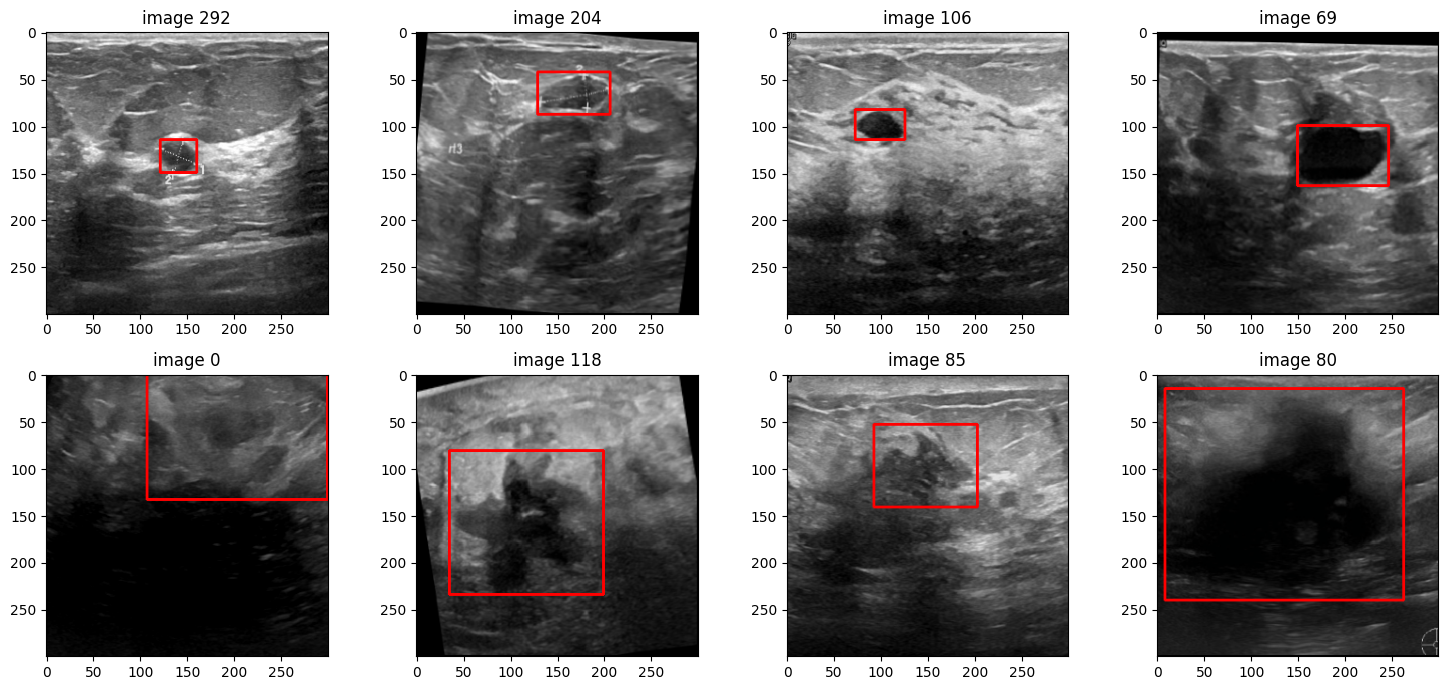

In [ ]:
# plot some augmented images
plt.figure(figsize=(15, 7))
for i in range(8):
  if i<4:
    idx = np.random.randint(0, len(benign_train))

    img, box = benign_train.__getitem__(idx)
  else:
    idx = np.random.randint(0, len(malignant_train))

    img, box = malignant_train.__getitem__(idx)

  img = img.permute(1,2,0).cpu().numpy()
  h_img, w_img, _ = img.shape

  x, y, w, h = box

  # 1. convert to pixel space
  x = x.item() * w_img
  y = y.item() * h_img
  w = w.item() * w_img
  h = h.item() * h_img

  # 2. fix negatives
  x = max(0, int(x))
  y = max(0, int(y))
  w = max(1, int(w))
  h = max(1, int(h))

  plt.subplot(2, 4, i+1)
  denorm_img = denormalize(img)
  bound_img = cv2.rectangle(denorm_img.copy(),
                            (x, y),
                            (x+w, y+h),
                            (255, 0, 0),
                            2)
  plt.imshow(bound_img)
  plt.title(f"image {idx}")
plt.tight_layout()

In [15]:
len(benign_train), len(benign_val), len(benign_test), len(malignant_train), len(malignant_val), len(malignant_test)

(305, 87, 45, 147, 42, 21)

In [16]:
# combining the Benign & Malignant datasets
train_data = torch.utils.data.ConcatDataset([benign_train, malignant_train])
val_data = torch.utils.data.ConcatDataset([benign_val, malignant_val])
test_data = torch.utils.data.ConcatDataset([benign_test, malignant_test])

In [18]:
len(train_data), len(val_data), len(test_data)

(452, 129, 66)

In [17]:
start_time = time()
train_dir = "dataset/train"
val_dir = "dataset/val"
# create directory if it doesn't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
for i in range(len(train_data)):
    tr_image, tr_label = train_data[i]   # <-- NOW data is loaded
    torch.save((tr_image, tr_label), f"{train_dir}/tr_{i}.pt")

for i in range(len(val_data)):
    val_image, val_label = val_data[i]
    torch.save((val_image, val_label), f"{val_dir}/val_{i}.pt")
print(f'tokes {time()-start_time}s')

tokes 19.944937467575073s


In [18]:
class CachedDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir):
        self.files = os.listdir(data_dir)
        self.data_dir = data_dir

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.data_dir, self.files[idx])
        image, bbox = torch.load(path, weights_only=False)
        return image, bbox

In [19]:
train_dataset = CachedDataset(train_dir)
val_dataset = CachedDataset(val_dir)
len(train_dataset), len(val_dataset)

(452, 129)

In [20]:
# add data loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=32, num_workers=2, shuffle=True, drop_last=True)
valid_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=32, num_workers=2, shuffle=True)

In [21]:
len(train_loader.dataset), len(valid_loader.dataset)

(452, 129)

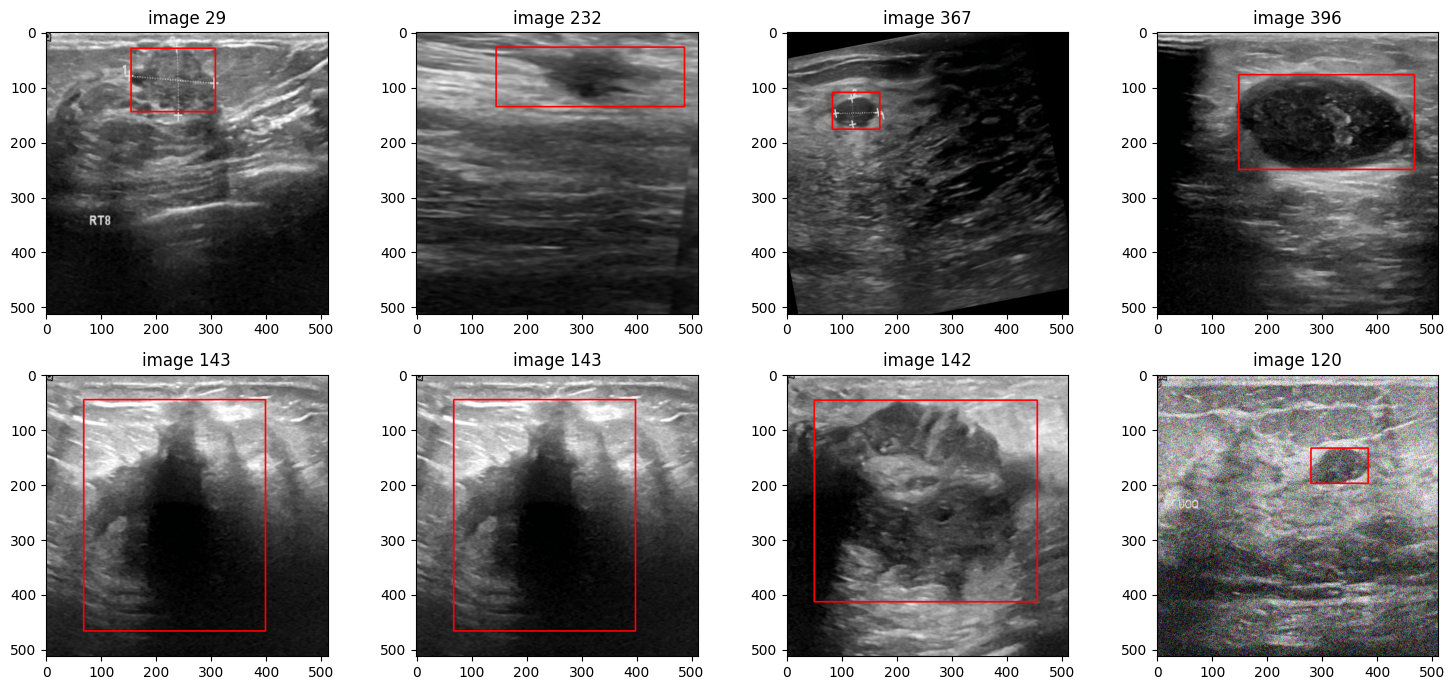

In [22]:
# plot some augmented images with bbox
plt.figure(figsize=(15, 7))
for i in range(8):
  idx = np.random.randint(0, len(train_loader.dataset))
  img, box = train_loader.dataset.__getitem__(idx)

  img = img.permute(1,2,0).cpu().numpy()
  h_img, w_img, _ = img.shape

  x, y, w, h = box

  # 1. convert to pixel space
  x = x.item() * w_img
  y = y.item() * h_img
  w = w.item() * w_img
  h = h.item() * h_img

  # 2. fix negatives
  x = max(0, int(x))
  y = max(0, int(y))
  w = max(1, int(w))
  h = max(1, int(h))

  plt.subplot(2, 4, i+1)
  denorm_img = denormalize(img)
  bound_img = cv2.rectangle(denorm_img.copy(),
                            (x, y),
                            (x+w, y+h),
                            (255, 0, 0),
                            2)
  plt.imshow(bound_img)
  plt.title(f"image {idx}")
plt.tight_layout()

In [23]:
# create Residual with skip connection support
class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, stride=stride),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),

            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c)
        )

        # match dimensions for skip connection
        if in_c != out_c or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_c)
            )
        else:
            self.skip = nn.Identity()

        self.relu = nn.ReLU()

    def forward(self, x):
        residual = self.skip(x)      # original path

        out = self.conv(x)           # transformed path

        out = out + residual
        out = self.relu(out)  #  RESIDUAL ADDED

        return out

In [138]:
# Builing the network
class Cnn_network(nn.Module):
  def __init__(self):
    super(Cnn_network, self).__init__()

    # Encoder
    self.block1 = nn.Sequential(
        ResidualBlock(3, 32, stride=2),
        ResidualBlock(32, 32, stride=1)
    )

    self.block2 = nn.Sequential(
        ResidualBlock(32, 64, stride=2),
        ResidualBlock(64, 64, stride=1)
    )

    self.block3 = nn.Sequential(
        ResidualBlock(64, 128, stride=2),
        ResidualBlock(128, 128, stride=1)
    )

    self.block4 = nn.Sequential(
        ResidualBlock(128, 256, stride=2),
        ResidualBlock(256, 256, stride=1)
    )

    # self.dropout = nn.Dropout2d(0.1)
    self.fuse_head = nn.Sequential(
        nn.Conv2d(256 + 128, 256, 1),
        nn.ReLU()
    )

    self.head = nn.Sequential(
        nn.Conv2d(256, 256, 3, padding=1),
        nn.ReLU(),

        nn.Conv2d(256, 128, 3, padding=1),
        nn.ReLU(),

        nn.Conv2d(128, 64, 3, padding=1),
        nn.ReLU(),

        nn.Conv2d(64, 4, 1),


        # nn.AdaptiveAvgPool2d(1),   # [B, 256, 1, 1]
        # nn.Flatten(),              # [B, 256]
        # nn.Linear(64, 4)          # [x, y, w, h, obj]
    )

  def forward(self, x):

    # Encoder
    x1 = self.block1(x)
    x2 = self.block2(x1)
    x3 = self.block3(x2)
    x4 = self.block4(x3) # <-- Bottleneck
    # x4 = self.dropout(x4) # <-- reduce noise at bottleneck

    # -------------------------
    # 🔥 FEATURE FUSION
    # -------------------------

    x4_up = nn.functional.interpolate(x4, size=x3.shape[2:])

    # combine deep + mid features
    fused = torch.cat([x3, x4_up], dim=1)

    fused = self.fuse_head(fused)

    # -------------------------
    # HEAD (bbox prediction)
    # -------------------------

    # output objects
    out = self.head(fused)
    out = torch.mean(out, dim=(2,3))  # global average ONLY at end
    return out
net = Cnn_network().to(device)
summary(net, input_size=(3, 512, 512))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 256, 256]             128
       BatchNorm2d-2         [-1, 32, 256, 256]              64
            Conv2d-3         [-1, 32, 256, 256]             896
       BatchNorm2d-4         [-1, 32, 256, 256]              64
              ReLU-5         [-1, 32, 256, 256]               0
            Conv2d-6         [-1, 32, 256, 256]           9,248
       BatchNorm2d-7         [-1, 32, 256, 256]              64
              ReLU-8         [-1, 32, 256, 256]               0
     ResidualBlock-9         [-1, 32, 256, 256]               0
         Identity-10         [-1, 32, 256, 256]               0
           Conv2d-11         [-1, 32, 256, 256]           9,248
      BatchNorm2d-12         [-1, 32, 256, 256]              64
             ReLU-13         [-1, 32, 256, 256]               0
           Conv2d-14         [-1, 32, 2

In [139]:
# test the model
dumy_dataset = torch.randn(1, 3, 300, 300).to(device)
# test the model
pred = net(dumy_dataset)
pred

tensor([[-0.0196, -0.0512,  0.0565,  0.0720]], device='cuda:0',
       grad_fn=<MeanBackward1>)

In [69]:
# CioU loss

def bbox_ciou(pred, target, eps=1e-7):
    """
    pred, target: [B, 4] → (x, y, w, h)
    """

    # Convert to corners
    pred_x1 = pred[:, 0] - pred[:, 2] / 2
    pred_y1 = pred[:, 1] - pred[:, 3] / 2
    pred_x2 = pred[:, 0] + pred[:, 2] / 2
    pred_y2 = pred[:, 1] + pred[:, 3] / 2

    target_x1 = target[:, 0] - target[:, 2] / 2
    target_y1 = target[:, 1] - target[:, 3] / 2
    target_x2 = target[:, 0] + target[:, 2] / 2
    target_y2 = target[:, 1] + target[:, 3] / 2

    # Intersection
    inter_x1 = torch.max(pred_x1, target_x1)
    inter_y1 = torch.max(pred_y1, target_y1)
    inter_x2 = torch.min(pred_x2, target_x2)
    inter_y2 = torch.min(pred_y2, target_y2)

    inter_area = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)

    # Areas
    pred_area = (pred_x2 - pred_x1) * (pred_y2 - pred_y1)
    target_area = (target_x2 - target_x1) * (target_y2 - target_y1)

    union = pred_area + target_area - inter_area + eps
    iou = inter_area / union

    # Center distance
    center_dist = (pred[:, 0] - target[:, 0])**2 + (pred[:, 1] - target[:, 1])**2

    # Enclosing box
    enc_x1 = torch.min(pred_x1, target_x1)
    enc_y1 = torch.min(pred_y1, target_y1)
    enc_x2 = torch.max(pred_x2, target_x2)
    enc_y2 = torch.max(pred_y2, target_y2)

    enc_diag = (enc_x2 - enc_x1)**2 + (enc_y2 - enc_y1)**2 + eps

    # Aspect ratio
    v = (4 / (torch.pi**2)) * torch.pow(
        torch.atan(target[:, 2] / target[:, 3]) -
        torch.atan(pred[:, 2] / pred[:, 3]), 2
    )

    alpha = v / (1 - iou + v + eps)

    ciou = iou - (center_dist / enc_diag) - alpha * v

    return 1 - ciou.mean()

In [ ]:
def l1_ciou_fun(pred, target):
    # Predictions
    pred_boxes = torch.sigmoid(pred)   # [B, 4]

    # Targets
    target_boxes = target[:, 0:4]

    # Losses
    l1 = nn.SmoothL1Loss()

    loss_ciou = bbox_ciou(pred_boxes, target_boxes)
    loss_l1   = l1(pred_boxes, target_boxes)

    loss_bbox = 0.2 * loss_ciou + 0.8 * loss_l1

    return loss_bbox

In [114]:
# define the compiler
optimizer = torch.optim.AdamW(params=net.parameters(), lr=0.000005, weight_decay=0.00001)
# ↑ (Adam with Weight Decay) decouples these, leading to better generalization more consistant decay

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, # Drops the learning rate when the validation loss stops improving
                                                       mode='min',
                                                       patience=2,
                                                       factor=0.5)

loss_fun = nn.SmoothL1Loss(reduction="mean")
# def loss_fun(pred, target):
#   return nn.SmoothL1Loss(reduction="mean")

In [70]:
# training method
def train(data_loader, loss_fun, optimizer):
  # print(f'is training: {net.training}')
  size = len(data_loader.dataset)
  training_loss = 0
  number_of_batches = len(data_loader)

  net.train(mode=True) # set the model in the training mode
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)

    # y = y.unsqueeze(1).float()
    # reset all the gradient
    optimizer.zero_grad()

    pred = net(X) # <-- directly calling the forward method

    loss = loss_fun(pred, y)

    loss.backward() # compute the gradient
    # at this point we computed the gradient
    torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0) # <-- Since my dataset is very small
    optimizer.step() # update the weights
    training_loss += loss.item()
    if (batch+1 == number_of_batches):
      print(f'Batch {batch+1}/{number_of_batches} | Loss: {loss.item():.4f}')

  return training_loss/number_of_batches


In [54]:
# Validate the model
def val_model(data_loader, loss_fun):
  val_loss = 0
  net.eval()
  with torch.no_grad(): # disable the grade calculation
    for data in data_loader:
      X, y = data
      X, y = X.to(device), y.to(device)
      # y = y.unsqueeze(1).float()

      pred = net(X) # <-- directly calling the forward method

      loss = loss_fun(pred, y)
      val_loss += loss.item()
  return val_loss/len(data_loader)

In [55]:
img, label = train_loader.dataset.__getitem__(0)
img.shape

torch.Size([3, 512, 512])

In [140]:
epoch = 15
history = {'tr_loss': [], 'val_loss': []}
best_val = float('inf')
patience = 8
counter = 0
best_epoch = 0
for i in range(epoch):
  print(f"Epoch {i}: ")
  tr_loss = train(train_loader, loss_fun, optimizer)
  history['tr_loss'].append(tr_loss)
  avg_loss = val_model(valid_loader, loss_fun)

  # update the learning rate
  scheduler.step(round(avg_loss, 4)) # <-- reduces noise sensitivity
  history['val_loss'].append(avg_loss)
  print(f"Validation loss: {avg_loss}")

  if avg_loss < best_val:
      best_val = avg_loss
      counter = 0
      best_epoch = i
      torch.save(net.state_dict(), "best_model.pth")
  else:
      counter += 1

  if counter >= patience:
      print("Early stopping!")
      break
print(f"Best model at epoch {best_epoch}")

Epoch 0: 
Batch 14/14 | Loss: 0.0595
Validation loss: 0.052072296291589736
Epoch 1: 
Batch 14/14 | Loss: 0.0601
Validation loss: 0.056823809444904325
Epoch 2: 
Batch 14/14 | Loss: 0.0587
Validation loss: 0.05717594176530838
Epoch 3: 
Batch 14/14 | Loss: 0.0505
Validation loss: 0.054192382097244265
Epoch 4: 
Batch 14/14 | Loss: 0.0698
Validation loss: 0.05037477128207683
Epoch 5: 
Batch 14/14 | Loss: 0.0529
Validation loss: 0.06665335297584533
Epoch 6: 
Batch 14/14 | Loss: 0.0548
Validation loss: 0.05029865726828575
Epoch 7: 
Batch 14/14 | Loss: 0.0536
Validation loss: 0.05245730578899384
Epoch 8: 
Batch 14/14 | Loss: 0.0570
Validation loss: 0.05778149366378784
Epoch 9: 
Batch 14/14 | Loss: 0.0558
Validation loss: 0.06188297048211098
Epoch 10: 
Batch 14/14 | Loss: 0.0597
Validation loss: 0.05116136483848095
Epoch 11: 
Batch 14/14 | Loss: 0.0553
Validation loss: 0.05686886534094811
Epoch 12: 
Batch 14/14 | Loss: 0.0563
Validation loss: 0.05215604454278946
Epoch 13: 
Batch 14/14 | Loss: 0

In [4]:
# Plot the loss curve
pd.DataFrame(history).plot()

In [117]:
model_path = '/content/best_model.pth'
# model_path = '/content/drive/MyDrive/Healthcare/BUSI/Models/bbox_m2.pt'

In [ ]:
# save the model
torch.save(net.state_dict(), model_path)

In [ ]:
# load the model
model = Cnn_network().to(device)

state_dict = torch.load(model_path, weights_only=True, map_location=torch.device('cpu'))
model.load_state_dict(state_dict)

model.eval()

In [92]:
test_data = torch.utils.data.ConcatDataset([benign_test, malignant_test])
test_loader = torch.utils.data.DataLoader(dataset=test_data, batch_size=32, num_workers=2, shuffle=True)


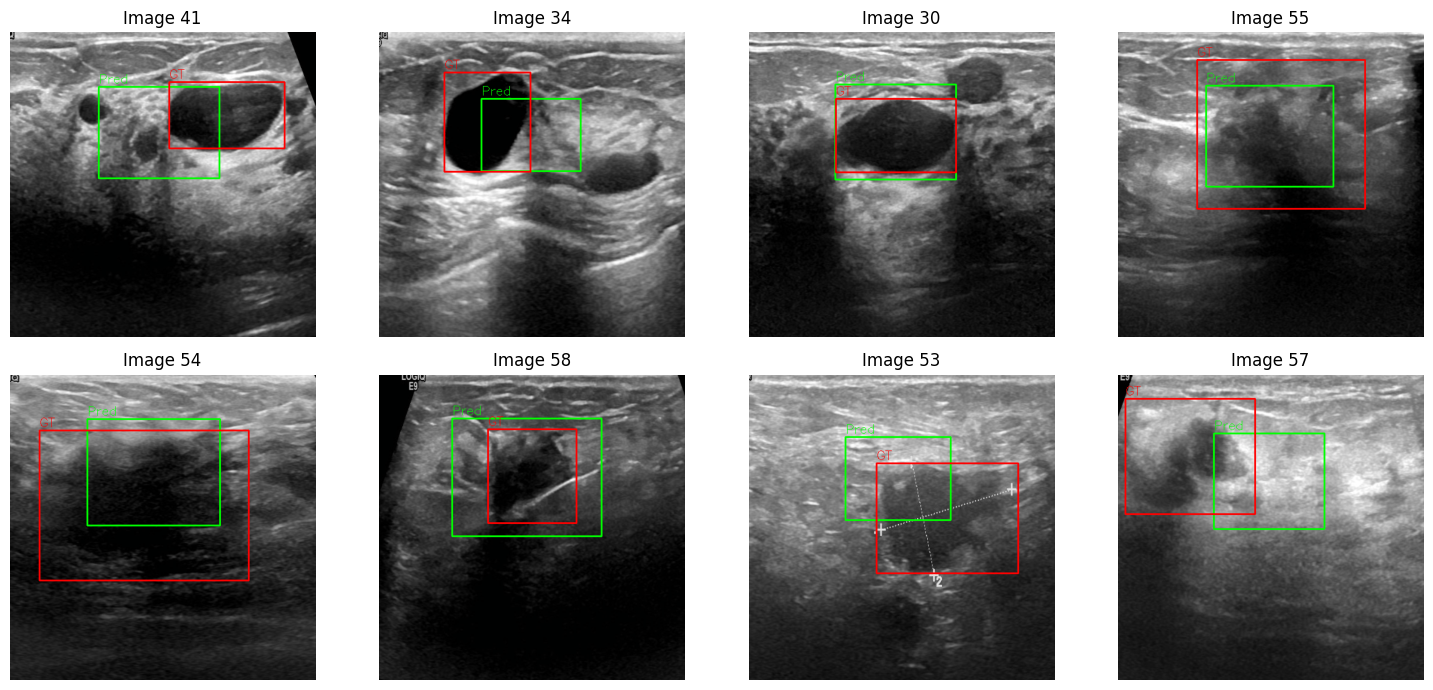

In [122]:

plt.figure(figsize=(15, 7))
for i in range(8):
  idx = np.random.randint(len(test_loader.dataset))
  img, bbox = test_loader.dataset[idx]
  pred_test = model(img.unsqueeze(0).to(device))

  img = img.permute(1,2,0).cpu().numpy()
  h_img, w_img, _ = img.shape

  x, y, w, h = pred_test[0].detach().cpu()

  # 1. convert to pixel space
  x = x.item() * w_img
  y = y.item() * h_img
  w = w.item() * w_img
  h = h.item() * h_img

  # 2. fix negatives
  x = max(0, int(x))
  y = max(0, int(y))
  w = max(1, int(w))
  h = max(1, int(h))

  # ground truth
  tx, ty, tw, th = bbox
  tx = tx.item()* w_img
  ty = ty.item()* h_img
  tw = tw.item()* w_img
  th = th.item()* h_img
  tx, ty, tw, th = map(int, [tx, ty, tw, th])

  img_copy = denormalize(img.copy())

  # draw predicted (green)
  cv2.rectangle(img_copy, (x, y), (x+w, y+h), (0, 255, 0), 2)

  # draw ground truth (red)
  cv2.rectangle(img_copy, (tx, ty), (tx+tw, ty+th), (255, 0, 0), 2)


  cv2.putText(img_copy, "Pred", (x, y-6),
              cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 1)

  cv2.putText(img_copy, "GT", (tx, ty-6),
              cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 1)
  plt.subplot(2, 4, i+1)
  plt.imshow(img_copy)
  plt.title(f'Image {idx}')
  plt.axis("off")
plt.tight_layout()